In [ ]:
from sklearn import tree
from sklearn.tree import plot_tree, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [ ]:
%load_ext rpy2.ipython

In [ ]:
iris = %R iris
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 6.1+ KB


In [ ]:
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa


In [ ]:
%%R
install.packages("DAAG")
library(DAAG)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘deldir’, ‘RcppEigen’, ‘png’, ‘jpeg’, ‘interp’, ‘rbibutils’, ‘latticeExtra’, ‘Rdpack’

trying URL 'https://cran.rstudio.com/src/contrib/deldir_2.0-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/png_0.1-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/jpeg_0.1-11.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/interp_1.1-6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/rbibutils_2.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/latticeExtra_0.6-31.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Rdpack_2.6.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/DAAG_1.25.6.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp9ope1d/downloaded_packages’


In [ ]:
spam = %R spam7

In [ ]:
y = iris["Species"]
X = iris.drop(["Species"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
iris_modelo = tree.DecisionTreeClassifier()
iris_modelo = iris_modelo.fit(X_train, y_train)
iris_pred = iris_modelo.predict(X_test)

In [ ]:
confusion_matrix(iris_pred, y_test)

array([[12,  0,  0],
       [ 0, 12,  2],
       [ 0,  2, 10]])

In [ ]:
lista_modelos = [tree.DecisionTreeClassifier(max_depth=i) for i in range(1,11)]
for modelo in lista_modelos:
    modelo = modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    print(accuracy_score(y_test, pred))

0.631578947368421
0.8947368421052632
0.8947368421052632
0.8947368421052632
0.8947368421052632
0.8947368421052632
0.8947368421052632
0.8947368421052632
0.8947368421052632
0.8947368421052632


In [ ]:
X.columns

Index(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width'], dtype='object')

[Text(0.4, 0.875, 'x[3] <= 0.75\ngini = 0.666\nsamples = 112\nvalue = [38, 36, 38]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 38\nvalue = [38, 0, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 1.65\ngini = 0.5\nsamples = 74\nvalue = [0, 36, 38]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[2] <= 5.25\ngini = 0.1\nsamples = 38\nvalue = [0, 36, 2]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 36\nvalue = [0, 0, 36]')]

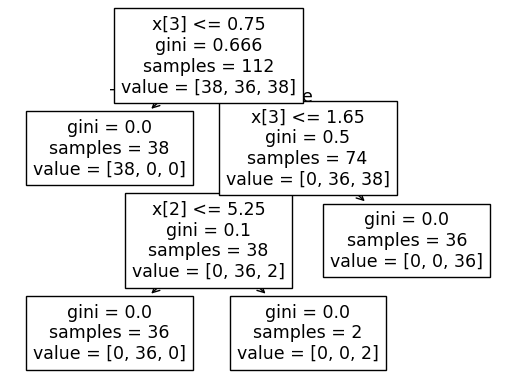

In [ ]:
tree.plot_tree(iris_modelo)

In [ ]:
import graphviz

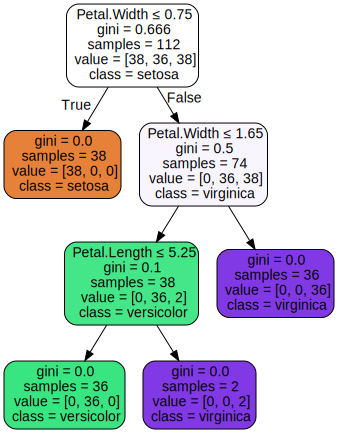

In [ ]:
dot_data = tree.export_graphviz(iris_modelo, out_file=None,
                     feature_names=iris.iloc[:,:4].columns,
                     class_names=iris.Species.unique(),
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
spam.head()

,crl.tot,dollar,bang,money,n000,make,yesno
1,278.0,0.000,0.778,0.00,0.00,0.00,y
2,1028.0,0.180,0.372,0.43,0.43,0.21,y
3,2259.0,0.184,0.276,0.06,1.16,0.06,y
4,191.0,0.000,0.137,0.00,0.00,0.00,y
5,191.0,0.000,0.135,0.00,0.00,0.00,y


In [ ]:
y = spam['yesno']
X = spam.drop('yesno', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
modelo = tree.DecisionTreeClassifier()
modelo = modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred)

array([[734,  96],
       [139, 412]])

In [ ]:
print(accuracy_score(y_pred, y_test))
print(precision_score(y_pred, y_test, pos_label="y"))
print(recall_score(y_pred, y_test, pos_label="y"))
print(f1_score(y_pred, y_test, pos_label="y"))

0.8298334540188269
0.7477313974591652
0.8110236220472441
0.7780925401322002
